In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import types
import xarray as xr
import sys
import pandas as pd
from scipy.spatial.distance import cdist


sys.path.append("../..")

from src import IOFunctions
IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions
MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import sCMOSFunctions
sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions
S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions
M_F = MaskFunctions.Mask_Functions()

from src import PSFFunctions
PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=True)

def euclidean_distance(ground_truth_points, fitted_points):
    """
    Calculates the minimum Euclidean distance from each fitted point to any ground truth point.

    This is appropriate for localization precision analysis where the number of
    fitted points may differ from the number of ground truth points.

    Args:
      ground_truth_points: A NumPy array of shape (n, 2) representing ground truth positions.
      fitted_points: A NumPy array of shape (m, 2) representing fitted positions.

    Returns:
      A NumPy array of shape (m,) containing the minimum distance from each fitted
      point to any ground truth point.
    """
    # Ensure both arrays are 2D
    ground_truth_points = np.atleast_2d(ground_truth_points)
    fitted_points = np.atleast_2d(fitted_points)

    # Calculate distance matrix and return minimum distance for each fitted point
    distance_matrix = np.linalg.norm(ground_truth_points - fitted_points, axis=1)
    return distance_matrix

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20260227_222604.log
/tmp/ipykernel_61832/2187897993.py:33: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=True)


In [2]:
# Import new refactored classes
from src.Multicolour_Simulation_Functions import (
    FittingStrategy,
    CameraParameters,
    SimulationConfig,
)

print("Imported new refactored classes successfully!")
print("Available fitting strategies:", [strategy.value for strategy in FittingStrategy])

Imported new refactored classes successfully!
Available fitting strategies: ['standard', 'demosaic', 'demosaic_fast', 'demosaic_ig']


In [3]:
data_folder = "../../Camera_Calibrations/Ximea_Camera/"
gain     = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset   = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe      = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [4]:
R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

# Smoothing function (Gaussian, sigma=1.5 px)
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [5]:
# Simulation parameters
dyes = ["ATTO 488", "ATTO 565", "ATTO 647N"]
filters = []

n_bootstrap = 50000
n_photon_space = np.array([2000, 4000], dtype=float)

pixel_size_space = np.arange(20, 505, 5)  # 20 to 500 nm in steps of 5 nm
physical_image_size_nm = 1500.0           # target physical FOV (nm); determines image_dims
NA = 1.49
background_photons = 0.0
cpu_fraction = 0.9

print(f"Bootstrap samples: {n_bootstrap}")
print(f"Photon levels: {n_photon_space}")
print(f"Pixel sizes: {pixel_size_space[0]} – {pixel_size_space[-1]} nm ({len(pixel_size_space)} steps)")

Bootstrap samples: 50000
Photon levels: [ 2000.  4000.]
Pixel sizes: 20 – 500 nm (97 steps)


In [6]:
save_folder = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260224_PixelSizeTest"
if not os.path.isdir(save_folder):
    os.makedirs(save_folder)
print(f"Results will be saved to: {save_folder}")

Results will be saved to: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260224_PixelSizeTest


In [7]:
# Pixel-size sweep
# For each pixel size, the image dimensions (in pixels) are chosen so the physical
# FOV stays close to physical_image_size_nm, with a minimum of 14 pixels.
print("Running pixel-size sweep...")
print("=" * 60)

for dye in dyes:
    for pixel_size in pixel_size_space:
        image_dims = max(14, int(np.ceil(physical_image_size_nm / pixel_size)))
    
        camera_params_dict = {
            "gain":      np.full((image_dims, image_dims), np.median(gain)),
            "offset":    np.full((image_dims, image_dims), np.median(offset)),
            "variance":  np.full((image_dims, image_dims), np.median(variance)),
            "readnoise": np.full((image_dims, image_dims), np.median(readnoise)),
            "rqe":       np.full((image_dims, image_dims), np.median(rqe)),
            "masks":     M_F.get_masks(size_x=image_dims, size_y=image_dims),
            "pixel_QYs": pixel_QYs,
            "pixel_order": ["B", "G", "R"],
            "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
        }
    
        config = SimulationConfig(
            n_bootstrap=n_bootstrap,
            background_photons=background_photons,
            NA=NA,
            pixel_size=float(pixel_size),
            cpu_fraction=cpu_fraction,
            save_raw_results=True,
            subtractx0y0=False,
            saverawimages=False,
            use_stochastic_photons=True,
            verbose=False,
        )
    
        print(f"  pixel_size={pixel_size} nm  image_dims={image_dims}x{image_dims}")
    
        MSF.test_simulation_method(
            dye=dye,
            filters=filters,
            wavelength=wavelength,
            camera_parameters=camera_params_dict,
            save_folder=save_folder,
            n_photon_space=n_photon_space,
            smoothing_function=smoothing_function,
            strategy=FittingStrategy.STANDARD,
            starting_flag=f"pixelsize_{pixel_size}nm_",
            config=config,
            overwrite=True,
        )
    
print("\nPixel-size sweep complete!")
print(f"Results saved to: {save_folder}")

Running pixel-size sweep...
  pixel_size=20 nm  image_dims=75x75
Analysed photon flux 2/2    Time elapsed: 2.986 min                             ?, ?it/s]
Completed analysis of 2 photon flux values    Total time: 2.986 min


INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard


  pixel_size=25 nm  image_dims=60x60
Analysed photon flux 2/2    Time elapsed: 2.251 min                             ?, ?it/s]
Completed analysis of 2 photon flux values    Total time: 2.251 min


INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard


  pixel_size=30 nm  image_dims=50x50
Analysed photon flux 2/2    Time elapsed: 1.756 min                             ?, ?it/s]
Completed analysis of 2 photon flux values    Total time: 1.756 min


...

  pixel_size=495 nm  image_dims=14x14
Analysed photon flux 2/2    Time elapsed: 0.663 min                             ?, ?it/s]
Completed analysis of 2 photon flux values    Total time: 0.663 min


INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard


  pixel_size=500 nm  image_dims=14x14
Analysed photon flux 2/2    Time elapsed: 0.656 min                             ?, ?it/s]
Completed analysis of 2 photon flux values    Total time: 0.656 min


INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard



Pixel-size sweep complete!
Results saved to: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260224_PixelSizeTest


In [8]:
save_folder = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260224_PixelSizeTest"
all_files = os.listdir(save_folder)
pixel_size_space = np.arange(20, 505, 5)  # 20 to 500 nm in steps of 5 nm
parameters = ["xy", "colour"]
n_photon_space = np.unique(n_photon_space)

In [9]:
from scipy.spatial.distance import cdist

Overall_XR = xr.DataArray(
    data=np.zeros([len(pixel_size_space), len(dyes), len(n_photon_space), len(parameters)]),
    coords=[pixel_size_space, dyes, n_photon_space, parameters],
    dims=["Pixel_Size", "Dye", "Photon", "Analysis_Parameter"],
)
physical_image_size_nm = 1500.0
for i, pixel_size in enumerate(pixel_size_space):
    image_dims = max(14, int(np.ceil(physical_image_size_nm / pixel_size)))
    loop_files = np.sort([x for x in all_files if f'pixelsize_{pixel_size}nm_' in x])
    for j, dye in enumerate(dyes):
        dye_file = np.sort(
            [os.path.join(save_folder, x) for x in loop_files if dye in x]
        )
        dye_file_raw = np.sort([x for x in dye_file if "rawresults" in x])
        dye_xy_gt = pd.read_csv(np.sort([x for x in dye_file if "groundtruth" in x])[0])
        # Ground truth positions are in nm; convert to pixels for this pixel_size
        dye_x0 = dye_xy_gt["x0"].to_numpy() / pixel_size
        dye_y0 = dye_xy_gt["y0"].to_numpy() / pixel_size
        x0y0 = np.vstack([dye_x0, dye_y0]).T
        dye_BGR = pd.read_csv(
            np.sort([x for x in dye_file if "input_parameters" in x])[0]
        ).to_numpy()[0][-3:]
        dye_BGR = dye_BGR / np.sum(dye_BGR)
        overall_results = pd.read_hdf(dye_file_raw[0])
        print(dye_file_raw[0])
        for k, photonval in enumerate(n_photon_space):
            results = overall_results[overall_results.photon_level == k]
            # Signed per-axis localisation errors (pixels)
            error_x = results["xc"].to_numpy() - x0y0[:, 0]
            error_y = results["yc"].to_numpy() - x0y0[:, 1]
            # Combined 1D precision: sqrt((var_x + var_y) / 2), converted to nm
            sigma_xy = np.sqrt((np.nanstd(error_x)**2 + np.nanstd(error_y)**2) / 2) * pixel_size
            colour_loc = np.expand_dims(dye_BGR, 0)
            colour = np.vstack(
                [
                    results["A_B"].to_numpy(),
                    results["A_G"].to_numpy(),
                    results["A_R"].to_numpy(),
                ]
            ).T
            colour_distances = cdist(colour, colour_loc)
            Overall_XR[i, j, k, 0] = sigma_xy
            Overall_XR[i, j, k, 1] = np.nanstd(colour_distances)

Overall_XR.to_netcdf(os.path.join(save_folder, "Pixelsize_Database_STDEV.nc"))

/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260224_PixelSizeTest/pixelsize_20nm_LM_method_ATTO 488_rawresults.h5
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260224_PixelSizeTest/pixelsize_20nm_LM_method_ATTO 565_rawresults.h5
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260224_PixelSizeTest/pixelsize_20nm_LM_method_ATTO 647N_rawresults.h5
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260224_PixelSizeTest/pixelsize_25nm_LM_method_ATTO 488_rawresults.h5
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260224_PixelSizeTest/pixelsize_25nm_LM_method_ATTO 565_rawresults.h5
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260224_PixelSizeTest/pixelsize_25nm_LM_method_ATTO 647N_rawresults.h5
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260224_PixelSizeTest/pixelsize_30nm_LM_method_ATTO 488_rawresults.h5
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulati

In [10]:
Overall_XR = xr.load_dataarray(os.path.join(save_folder, "Pixelsize_Database_STDEV.nc"))

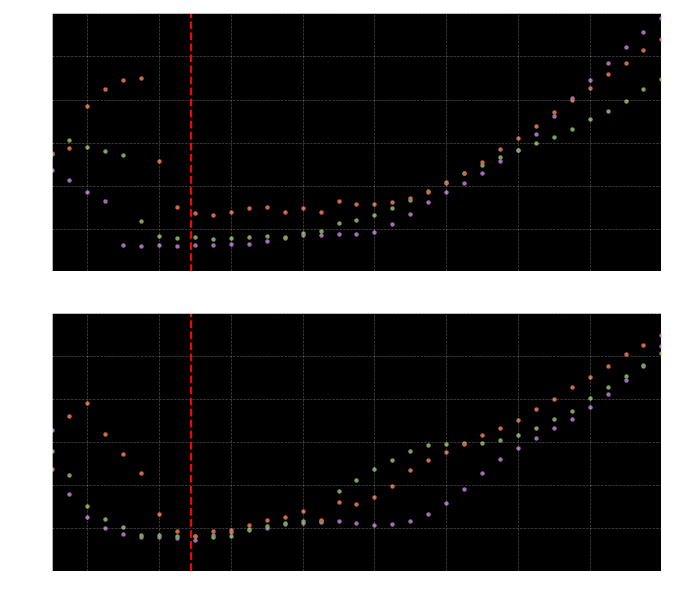

In [11]:
fig, axs = plotter.two_column_plot(nrows=2, heightratio=[1,1])


colours = ["#a46cb7",
"#7aa457",
"#cb6a49"]

for i in np.arange(3):
    axs[0] = plotter.scatter_plot(axs[0], x=pixel_size_space, y=np.squeeze(np.array(Overall_XR[:, i, 1, 0])), facecolor=colours[i], lw=0, s=10)


for i in np.arange(3):
    axs[1] = plotter.scatter_plot(axs[1], x=pixel_size_space, y=np.squeeze(np.array(Overall_XR[:, i, 1, 1])), facecolor=colours[i], lw=0, s=10)

for i in np.arange(2):
    axs[i].vlines(x=69, ymin=0, ymax=500, ls='--', color='red')
    axs[i].set_xlim([30, 200])

axs[0].set_ylim([0.1, 30])
axs[1].set_ylim([0, 0.12])

fig_savefolder = (
    "/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Conference Presentations/20260302_DurhamTalks/Research/fig/multicolour_camera/pixel_size/"
)
plt.savefig(os.path.join(fig_savefolder, 'Pixel_Size_StandardUnits.svg'), dpi=600, format='svg')
plt.show()

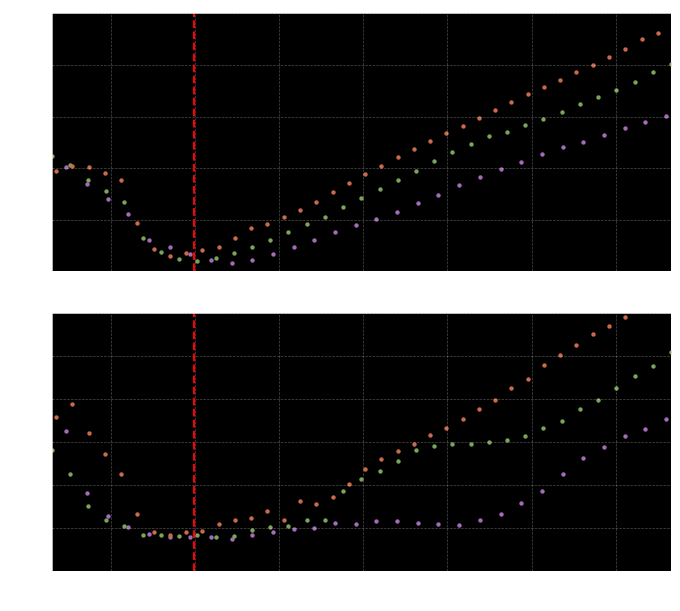

In [39]:
fig, axs = plotter.two_column_plot(nrows=2, heightratio=[1,1])


colours = ["#a46cb7",
"#7aa457",
"#cb6a49"]



for i in np.arange(3):
    axs[0] = plotter.scatter_plot(axs[0], x=pixel_size_space/psf_widths[i], y=np.squeeze(np.array(Overall_XR[:, i, 1, 0])), facecolor=colours[i], lw=0, s=10)


for i in np.arange(3):
    axs[1] = plotter.scatter_plot(axs[1], x=pixel_size_space/psf_widths[i], y=np.squeeze(np.array(Overall_XR[:, i, 1, 1])), facecolor=colours[i], lw=0, s=10)

for i in np.arange(2):
    axs[i].vlines(x=69/np.mean(psf_widths), ymin=0, ymax=500, ls='--', color='red')
    axs[i].set_xlim([30/np.mean(psf_widths), 200/np.mean(psf_widths)])

axs[0].set_ylim([0.1, 100])
axs[1].set_ylim([0, 0.12])

fig_savefolder = (
    "/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Conference Presentations/20260302_DurhamTalks/Research/fig/multicolour_camera/pixel_size/"
)
plt.savefig(os.path.join(fig_savefolder, 'Pixel_Size_ReducedUnits.svg'), dpi=600, format='svg')
plt.show()

In [40]:
average_wavelengths, QEs = S_F.get_pixel_fractions_dye_and_filters(dyes, filters=[], wavelength=wavelength, pixel_QYs=pixel_QYs)

In [25]:
psf_widths = PSF.sigma_PSF(average_wavelengths, NA=1.49)

array([ 0.23391023,  1.35135312,  1.41473665])